## Residuals vs Predictor

### PART 1 — Basic Residuals vs Predictor Plot

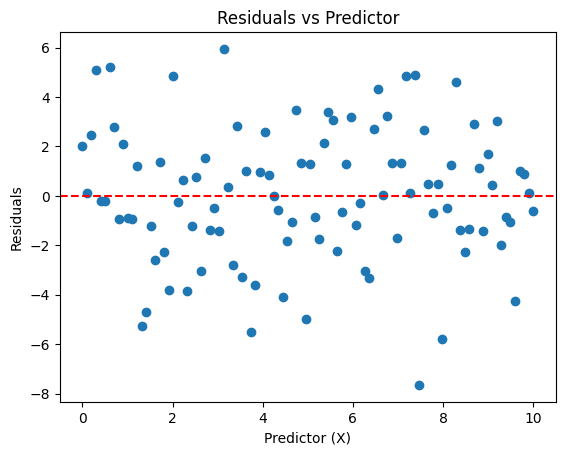

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

np.random.seed(42)

x = np.linspace(0, 10, 100)
y = 3 * x + np.random.normal(0, 3, 100)

df = pd.DataFrame({"X": x, "Y": y})

# Fit regression
X = sm.add_constant(df["X"])
model = sm.OLS(df["Y"], X).fit()

# Residuals
residuals = model.resid

plt.scatter(df["X"], residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predictor (X)")
plt.ylabel("Residuals")
plt.title("Residuals vs Predictor")
plt.show()


### PART 2 — Residuals vs Predictor with LOWESS smoothing

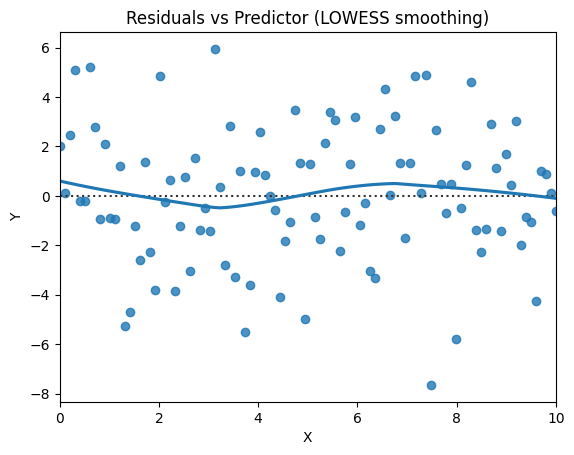

In [2]:
import seaborn as sns

sns.residplot(
    x="X",
    y="Y",
    data=df,
    lowess=True
)

plt.title("Residuals vs Predictor (LOWESS smoothing)")
plt.show()



### PART 3 — Residuals vs Predictor (Styled & Clear)


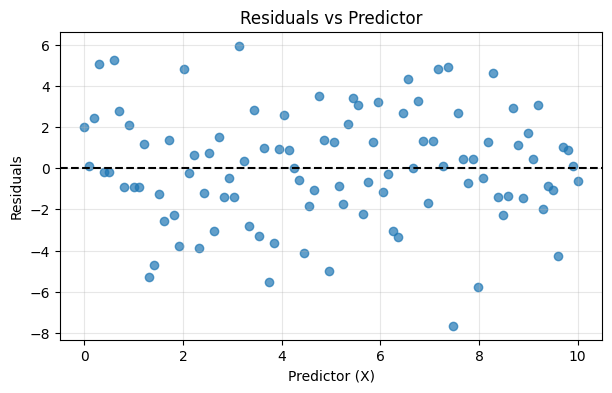

In [3]:
plt.figure(figsize=(7, 4))
plt.scatter(df["X"], residuals, alpha=0.7)
plt.axhline(0, color="black", linestyle="--")

plt.xlabel("Predictor (X)")
plt.ylabel("Residuals")
plt.title("Residuals vs Predictor")
plt.grid(alpha=0.3)

plt.show()


### PART 4 — Standardized Residuals vs Predictor

Better for detecting outliers.

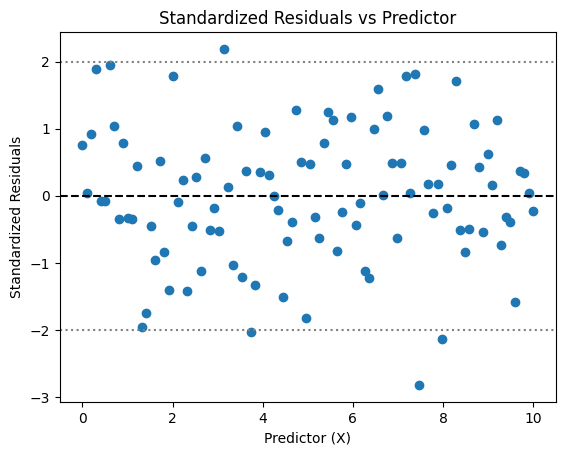

In [4]:
influence = model.get_influence()
std_resid = influence.resid_studentized_internal

plt.scatter(df["X"], std_resid)
plt.axhline(0, color="black", linestyle="--")
plt.axhline(2, color="gray", linestyle=":")
plt.axhline(-2, color="gray", linestyle=":")

plt.xlabel("Predictor (X)")
plt.ylabel("Standardized Residuals")
plt.title("Standardized Residuals vs Predictor")
plt.show()


### PART 5 — Multiple Predictors: Residuals vs Each Predictor

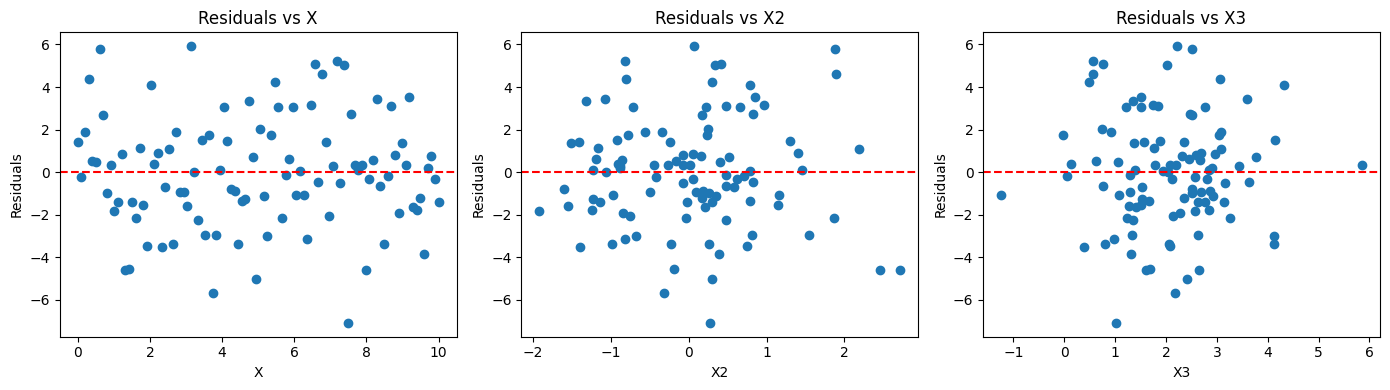

In [5]:
df["X2"] = np.random.normal(0, 1, len(df))
df["X3"] = np.random.normal(2, 1, len(df))

X_multi = sm.add_constant(df[["X", "X2", "X3"]])
model_multi = sm.OLS(df["Y"], X_multi).fit()

residuals_multi = model_multi.resid

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ["X", "X2", "X3"]):
    ax.scatter(df[col], residuals_multi)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_xlabel(col)
    ax.set_ylabel("Residuals")
    ax.set_title(f"Residuals vs {col}")

plt.tight_layout()
plt.show()


### PART 6 — Residuals vs Predictor (Polynomial Model)

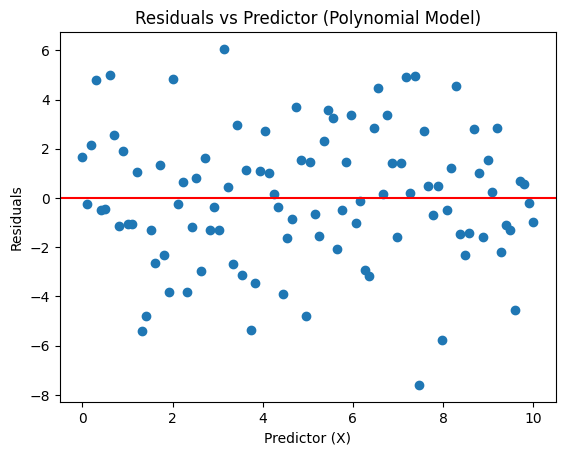

In [6]:
df["X2"] = df["X"] ** 2
X_poly = sm.add_constant(df[["X", "X2"]])

model_poly = sm.OLS(df["Y"], X_poly).fit()

res_poly = model_poly.resid

plt.scatter(df["X"], res_poly)
plt.axhline(0, color="red")
plt.xlabel("Predictor (X)")
plt.ylabel("Residuals")
plt.title("Residuals vs Predictor (Polynomial Model)")
plt.show()


### PART 7 — Heteroscedastic Data Example (Educational)

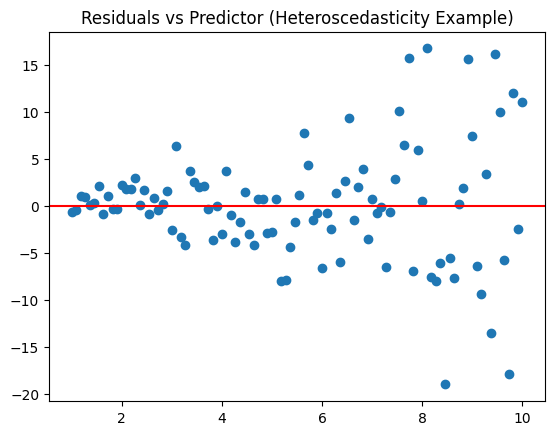

In [7]:
x = np.linspace(1, 10, 100)
y = 2 * x + np.random.normal(0, x, 100)  # increasing variance

df_het = pd.DataFrame({"X": x, "Y": y})

X = sm.add_constant(df_het["X"])
model = sm.OLS(df_het["Y"], X).fit()

res = model.resid

plt.scatter(df_het["X"], res)
plt.axhline(0, color="red")
plt.title("Residuals vs Predictor (Heteroscedasticity Example)")
plt.show()


### PART 8 — Residuals vs Predictor (With Color Encoding)

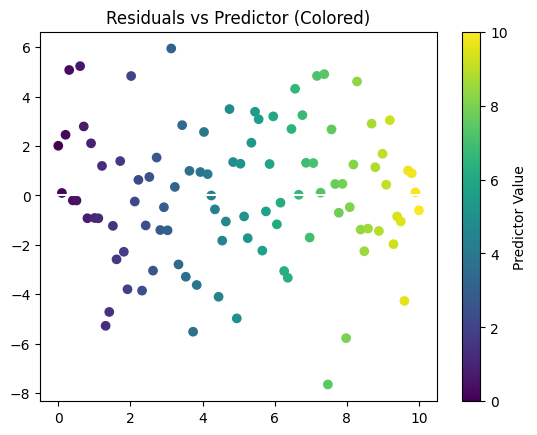

In [8]:
plt.scatter(
    df["X"],
    residuals,
    c=df["X"],
    cmap="viridis"
)
plt.colorbar(label="Predictor Value")
plt.axhline(0, color="white")
plt.title("Residuals vs Predictor (Colored)")
plt.show()


### PART 9 — Interactive Residuals vs Predictor (Plotly)

In [9]:
import plotly.express as px

fig = px.scatter(
    df,
    x="X",
    y=residuals,
    title="Interactive Residuals vs Predictor",
    labels={"y": "Residuals"}
)

fig.add_hline(y=0)
fig.show()


### PART 10 — Reusable Function (Professional Style)

In [10]:
def residuals_vs_predictor(df, predictor, target):
    X = sm.add_constant(df[predictor])
    model = sm.OLS(df[target], X).fit()

    residuals = model.resid
    std_resid = model.get_influence().resid_studentized_internal

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].scatter(df[predictor], residuals)
    axes[0].axhline(0, color="red")
    axes[0].set_title("Residuals vs Predictor")

    axes[1].scatter(df[predictor], std_resid)
    axes[1].axhline(0, color="red")
    axes[1].axhline(2, color="gray", linestyle=":")
    axes[1].axhline(-2, color="gray", linestyle=":")
    axes[1].set_title("Standardized Residuals")

    plt.tight_layout()
    plt.show()
